In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sympy.stats import Normal, sample

In [3]:
# Set random seed for reproducibility
np.random.seed(42)

There is a value in a highly sensitive dataset.

In [4]:
true_value = 18.0

The data owner determines the distribution from which they should draw noise before releasing the data.

In [5]:
sigma = 1.0
noise_dist = Normal('noise', mean=0, std=sigma)

The data owner applies the noise, effectively drawing a noisy value from a distribution like so.

In [6]:
sampled_value = true_value + sample(noise_dist)

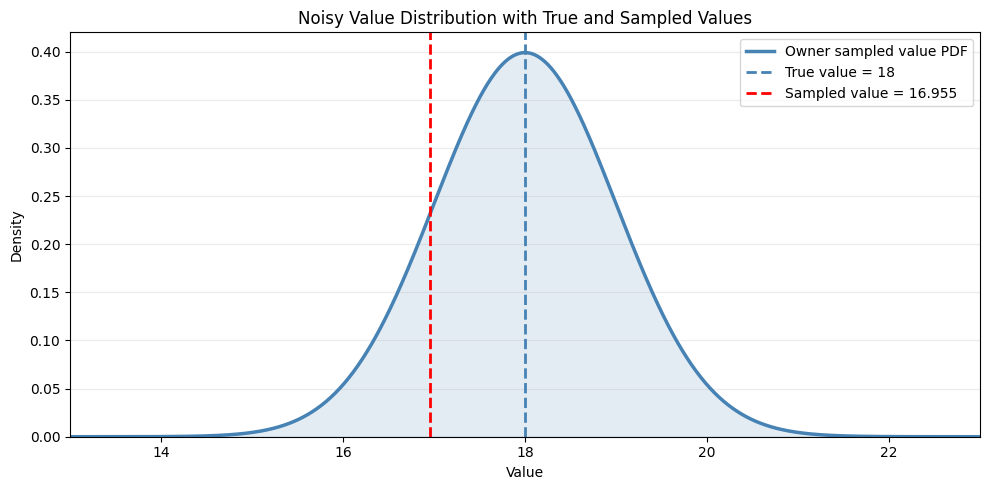

In [9]:
from statistics import NormalDist

nd = NormalDist(mu=true_value, sigma=sigma)
x = np.linspace(true_value - 5 * sigma, true_value + 5 * sigma, 1000)
owner_pdf = np.array([nd.pdf(v) for v in x])

plt.figure(figsize=(10, 5))
plt.plot(x, owner_pdf, color='steelblue', linewidth=2.5, label='Owner sampled value PDF')
plt.fill_between(x, owner_pdf, color='steelblue', alpha=0.15)
plt.axvline(true_value, color='steelblue', linestyle='--', linewidth=2, label=f'True value = {true_value:g}')
plt.axvline(sampled_value, color='red', linestyle='--', linewidth=2, label=f'Sampled value = {sampled_value:.3f}')
plt.xlim(13, 23)
plt.ylim(0, 0.42)
plt.title('Noisy Value Distribution with True and Sampled Values')
plt.xlabel('Value')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

The data owner publishes the data and the noise distribution used to privatize it. An analyst is interested in the noisy value. But how much to trust it?

If only the analyst could see the PMF. They can't (in fact the PMF reveals the true value), but perhaps they can approximate. The analyst knows the noise distribution, just not where to put it. Try centering it on the noisy value? Near-zero noise values are more likely than large noise values, after all.

But there is a problem. The mean from the analyst's perspective is itself noisy.

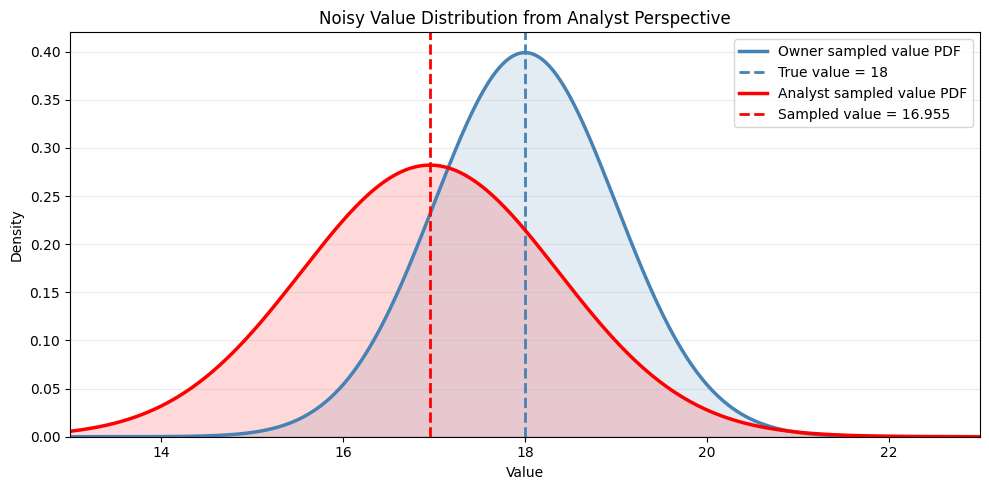

In [12]:
from statistics import NormalDist

nd = NormalDist(mu=sampled_value, sigma=sigma * np.sqrt(2))
analyst_pdf = np.array([nd.pdf(v) for v in x])

plt.figure(figsize=(10, 5))
plt.plot(x, owner_pdf, color='steelblue', linewidth=2.5, label='Owner sampled value PDF')
plt.fill_between(x, owner_pdf, color='steelblue', alpha=0.15)
plt.axvline(true_value, color='steelblue', linestyle='--', linewidth=2, label=f'True value = {true_value:g}')
plt.plot(x, analyst_pdf, color='red', linewidth=2.5, label='Analyst sampled value PDF')
plt.fill_between(x, analyst_pdf, color='red', alpha=0.15)
plt.axvline(sampled_value, color='red', linestyle='--', linewidth=2, label=f'Sampled value = {sampled_value:.3f}')
plt.xlim(13, 23)
plt.ylim(0, 0.42)
plt.title('Noisy Value Distribution from Analyst Perspective')
plt.xlabel('Value')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()